## EJERCICIO 01: Evaluación de solicitud de crédito bancario

### FICHA PEAS

>**Objetivo:** Aprobar créditos que se puedan pagar y rechazar aquellos que presenten un algot riesgo de no hacerlo.
>
>**Medidad de desempeño (P):** Con la tasa de morosidad de cartera aprobada...
>
>**Entorno (E):** Plataforma de evaluación de crédito de un banco, en la que se reciben solicitudes continuamente.
>
>**Acciones (A):** Aprobar la solicitud bajo condiciones o rechazar la solicitud .
>
>**Percepción (S):** Formulario de solicitud y de central de riesgos, que indica: ingreso_mensual (soles), monto_solicitado (soles) y tiene_historial:moroso (True/False).

## REGLAS DE DESICIÓN

|Historial|Relación monot e ingreso|Acción|
|---|---|---|
|Moroso|relación <= 0.30|Aprobar bajo condiciones|
|Moroso|relación > 0.30|Rechazar|
|No moroso|relación <= 0.50|Aprobar|
|No moroso|0.50 < relación <= 1.00|Aprobar bajo condiciones|
|No moroso|relación > 1.0| Rechazar|

## JUSTIFICACIÓN DE LAS REGLAS
La relación entre el monto y el ingreso es un indicador directo de carga financiera que el crédito representa para el solicitante. Si alguien pide prestado mucho más de lo que gana al mes, le costará más pagarlo. Por eso el banco aprueba sin problema solo cuando el préstamo es pequeño frente a su sueldo cómo la mitad o menos. En la zona intermedia no rechaza de una vez, sino que aprueba bajo algunas condiciones cómo por ejemplo: menos monto, más plazo o una garantía. Porque rechazar a todos esos clientes sería perder negocio. Si la persona ya dejó de pagar antes, el banco se pone más estricto, porque eso ya es una falla comprobada y no solo una sospecha. Así las reglas evitan prestar a quien no puede pagar, sin cerrarle la puerta a los buenos clientes.

## CÓDIGO

In [3]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    relacion = monto_solicitado / ingreso_mensual
    if tiene_historial_moroso:
        if relacion <= 0.30:
            return ("Aprobar condiciones",
                    f"Historial mosoro, pero relacion monto/ingreso baja ({relacion:.2f} <= 0.30)")
        else:
            return ("Rechazar",
                    f"Historial moroso y relacion monto/ingreso mayor a 0.30 ({relacion:.2f})")
    else:
        if relacion <= 0.50:
            return ("Aprobar",
                    f"Sin historial moroso y relación monto/ingreso bajo ({relacion:.2f} <= 0.50)")
        elif relacion <= 1.00:
            return ("Aprobar con condiciones",
                    f"Sin historial moroso, pero relación monto/ingreso intermedia ({relacion:.2f}")
        else:
            return ("Rechazar",
                    f"Relación monto/ingreso mayor a 1.00 ({relacion:.2f}): Ssupera su ingreso mensual completo")

## SIMULACIÓN Y PRUEBAS
Se prueban 7 combinaciones. El caso límite es la solicitud de S/1500 con sueldo de S/3000. La erlación es exactamente 0.50, justo en el borde entre aprobar o aprobar sin condiciones. 

In [4]:
casos = [ (3000, 1000, False), (3000, 1500, False), (3000, 1600, False), (3000, 2500, False),
          (3000, 3500, False), (4000, 1200, True), (4000, 2000, True)]

print (f"{'Ingreso':>8} {'Monto':>8} {'Moroso':>7} {'Relacion':>9} Acción/Motivo")
print ("-" * 110)
for ingreso, monto, moroso in casos:
    accion, motivo = agente_credito (ingreso, monto, moroso)
    relacion = monto / ingreso
    print (f"{ingreso:>8} {monto:>8} {str(moroso):>7} { relacion:>9.2f} { accion.upper()} -> {motivo}")

 Ingreso    Monto  Moroso  Relacion Acción/Motivo
--------------------------------------------------------------------------------------------------------------
    3000     1000   False      0.33 APROBAR -> Sin historial moroso y relación monto/ingreso bajo (0.33 <= 0.50)
    3000     1500   False      0.50 APROBAR -> Sin historial moroso y relación monto/ingreso bajo (0.50 <= 0.50)
    3000     1600   False      0.53 APROBAR CON CONDICIONES -> Sin historial moroso, pero relación monto/ingreso intermedia (0.53
    3000     2500   False      0.83 APROBAR CON CONDICIONES -> Sin historial moroso, pero relación monto/ingreso intermedia (0.83
    3000     3500   False      1.17 RECHAZAR -> Relación monto/ingreso mayor a 1.00 (1.17): Ssupera su ingreso mensual completo
    4000     1200    True      0.30 APROBAR CONDICIONES -> Historial mosoro, pero relacion monto/ingreso baja (0.30 <= 0.30)
    4000     2000    True      0.50 RECHAZAR -> Historial moroso y relacion monto/ingreso mayor a 0.

## VISUALIZACIÓN
Se generan 200 solicitudes aleatorias con numpy.random, se evalúa cada una con el agente y se grafica un scatter de relación vs ingreso_mensual, con un color por cada una de las tres desiciones posibles. 

accion
Rechazar                   78
Aprobar                    56
Aprobar con condiciones    54
Aprobar condiciones        12


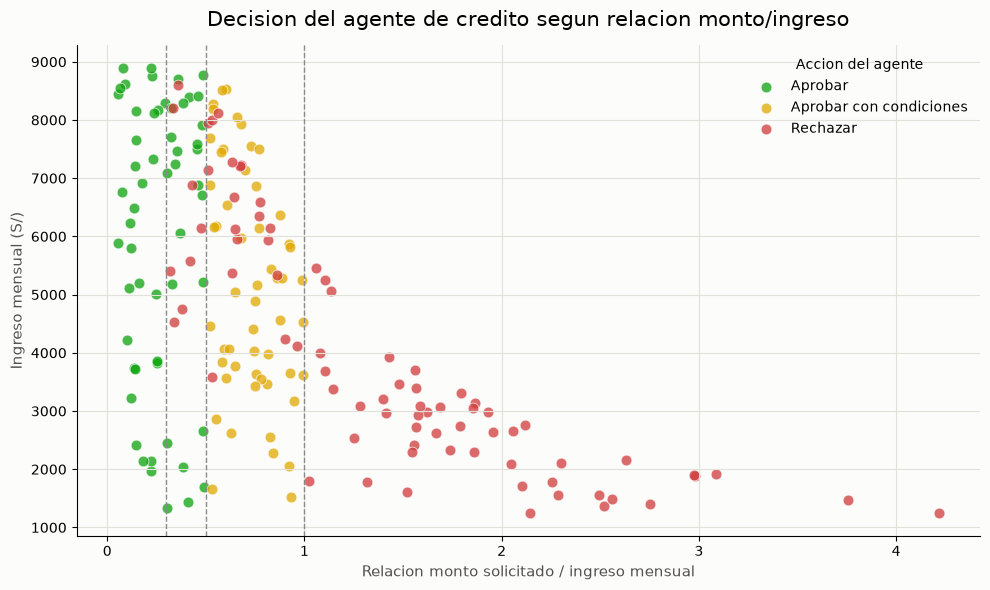

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
n = 200

ingresos = np.random.uniform(1200, 9000, n)               # ingreso mensual en soles
montos = np.random.uniform(300, 6000, n)                  # monto solicitado en soles
morosos = np.random.rand(n) < 0.25                        # 30% con historial moroso

registros = []
for ingreso, monto, moroso in zip(ingresos, montos, morosos):
    accion, motivo = agente_credito(ingreso, monto, bool(moroso))
    registros.append({
        "ingreso_mensual": ingreso,
        "monto_solicitado": monto,
        "tiene_historial_moroso": bool(moroso),
        "relacion": monto / ingreso,
        "accion": accion,
    })

solicitudes = pd.DataFrame(registros)
print(solicitudes["accion"].value_counts().to_string())

colores = {
    "Aprobar": "#0ca30c",
    "Aprobar con condiciones": "#e0a800",
    "Rechazar": "#d03b3b",
}

fig, ax = plt.subplots(figsize=(10, 6), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

for accion, color in colores.items():
    subset = solicitudes[solicitudes["accion"] == accion]
    ax.scatter(
        subset["relacion"], subset["ingreso_mensual"],
        s=60, alpha=0.75, c=color,
        edgecolors="white", linewidths=0.6,
        label=accion,
    )

ax.axvline(0.30, color="#8a8a8a", linestyle="--", linewidth=1)
ax.axvline(0.50, color="#8a8a8a", linestyle="--", linewidth=1)
ax.axvline(1.00, color="#8a8a8a", linestyle="--", linewidth=1)

ax.set_title("Decision del agente de credito segun relacion monto/ingreso", fontsize=15, pad=14)
ax.set_xlabel("Relacion monto solicitado / ingreso mensual", fontsize=11, color="#52514e")
ax.set_ylabel("Ingreso mensual (S/)", fontsize=11, color="#52514e")
ax.grid(True, color="#e1e0d9", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Accion del agente", frameon=False, loc="upper right")
plt.tight_layout()
plt.show()
